<a href="https://colab.research.google.com/github/ArdhanFah/PCVK/blob/main/Week-02/Praktikum.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [42]:
from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive/PCVK/

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/PCVK


**PERTANYAAN PRAKTIKUM**

Jawab pertanyaan berikut pada sel Markdown di dalam notebook Anda. Setiap jawaban yang menyebut nilai atau ukuran wajib disertai keluaran program.



1. Tampilkan satu citra bebas menggunakan cv2_imshow() dan plt.imshow() tanpa konversi warna apa pun. Mengapa hasilnya berbeda? Buktikan dengan mencetak nilai satu piksel yang sama dari kedua cara pembacaan tersebut.

    **Jawaban** : Hasilnya berbeda karena *cv2.imread()* membaca format BGR, sementara *plt.imshow() *mengasumsikan format RGB sehingga warna merah dan biru tertukar; pembuktian nilai piksel yang sama di (y, x) menunjukkan urutan nilainya terbalik pada kanal 0 dan 2.

Tampilan cv2_imshow:


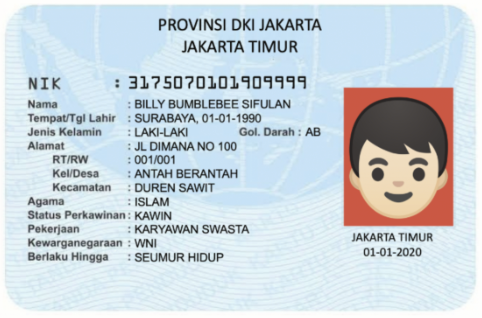

Tampilan plt.imshow:


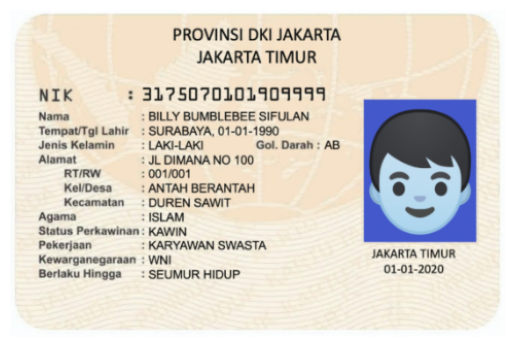

Nilai piksel di (50, 50): [247 235 216]
Kanal 0: 247, Kanal 1: 235, Kanal 2: 216


In [43]:
import cv2 as cv
import matplotlib.pyplot as plt
from google.colab.patches import cv_imshow

img_cv = cv.imread("KTP.png")

# Tampilan menggunakan cv2_imshow
print("Tampilan cv2_imshow:")
cv_imshow(img_cv)


# Tampilan menggunakan plt.imshow
print("Tampilan plt.imshow:")
plt.imshow(img_cv)
plt.axis("off")
plt.show()

# Bukti nilai piksel pada koordinat yang sama (misal y=50, x=50)
pixel_val = img_cv[50, 50]
print(f"Nilai piksel di (50, 50): {pixel_val}")
print(f"Kanal 0: {pixel_val[0]}, Kanal 1: {pixel_val[1]}, Kanal 2: {pixel_val[2]}")

2. Buat kanvas hitam berukuran sama dengan tipe data int16 dan int32. Bandingkan dtype, min(), max(), dan nbytes keduanya. Apakah tampilannya berbeda? Apakah ukuran memorinya berbeda? Jelaskan alasannya.

    **Jawaban** : Tampilannya sama persis karena seluruh piksel bernilai nol (hitam), tetapi ukuran memorinya berbeda karena *int32* memakai empat bita per piksel, sedangkan *int16* hanya memakai dua bita sehingga memorinya berukuran dua kali lipat lebih besar.

In [44]:
import numpy as np

canvas_int16 = np.zeros((300, 300), dtype=np.int16)
canvas_int32 = np.zeros((300, 300), dtype=np.int32)

print(f"Canvas int16 -> Dtype: {canvas_int16.dtype}, Min: {canvas_int16.min()}, Max: {canvas_int16.max()}, Nbytes: {canvas_int16.nbytes} bytes")
print(f"Canvas int32 -> Dtype: {canvas_int32.dtype}, Min: {canvas_int32.min()}, Max: {canvas_int32.max()}, Nbytes: {canvas_int32.nbytes} bytes")

Canvas int16 -> Dtype: int16, Min: 0, Max: 0, Nbytes: 180000 bytes
Canvas int32 -> Dtype: int32, Min: 0, Max: 0, Nbytes: 360000 bytes


3. Apa kegunaan baris from google.colab.patches import cv2_imshow, dan mengapa cv2.imshow() bawaan OpenCV tidak dapat dipakai di Google Colab?

    ***Jawaban*** :Baris tersebut digunakan untuk menampilkan gambar langsung di dalam sel Google Colab, karena fungsi cv2.imshow() bawaan membutuhkan sistem antarmuka grafis (GUI) lokal yang tidak didukung oleh lingkungan cloud Colab sehingga akan memicu galat.

4. Citra yang dibaca dengan skimage.io.imread() ditampilkan berdampingan dengan hasil cv2.cvtColor(img, cv2.COLOR_BGR2RGB) atas citra yang sama. Manakah yang menampilkan warna sebenarnya, dan manakah yang kanalnya tertukar? Buktikan dengan nilai piksel, bukan dengan pengamatan visual saja.


    ***Jawaban*** : Keduanya sama-sama menampilkan warna sebenarnya tanpa ada kanal yang tertukar, dibuktikan dari nilai piksel pada koordinat yang sama bernilai identik karena skimage.io.imread() secara default berformat RGB dan citra OpenCV sudah dikonversi ke RGB.

Piksel skimage.io  : [216 235 247 255]
Piksel cvtColor RGB: [216 235 247]
Piksel cv.imread asli (BGR): [247 235 216]


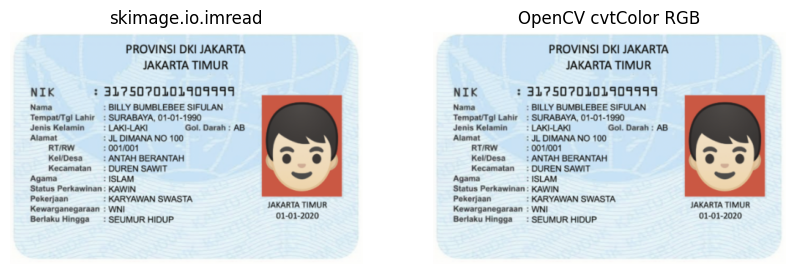

In [45]:
import cv2 as cv
import skimage.io as io
import matplotlib.pyplot as plt

# Pembacaan citra
img_skimage = io.imread("KTP.png")
img_opencv = cv.imread("KTP.png")
img_opencv_rgb = cv.cvtColor(img_opencv, cv.COLOR_BGR2RGB)
print("Piksel skimage.io  :", img_skimage[50, 50])
print("Piksel cvtColor RGB:", img_opencv_rgb[50, 50])
print("Piksel cv.imread asli (BGR):", img_opencv[50, 50])

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img_skimage)
axes[0].set_title("skimage.io.imread")
axes[0].axis("off")

axes[1].imshow(img_opencv_rgb)
axes[1].set_title("OpenCV cvtColor RGB")
axes[1].axis("off")
plt.show()

5. Setelah citra ditampilkan dengan figsize yang jauh lebih besar, apakah nilai img.shape ikut berubah? Jelaskan perbedaan antara mengubah ukuran citra dan mengubah ukuran tampilan.

    ***jawaban*** : Nilai img.shape tidak berubah sama sekali; mengubah ukuran citra memodifikasi jumlah data piksel dan dimensi matriks aslinya di memori, sedangkan mengubah ukuran tampilan (figsize) hanya memperbesar bidang kanvas gambar di layar tanpa mengubah datanya.

Shape sebelum visualisasi: (318, 482, 3)


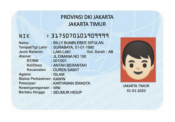

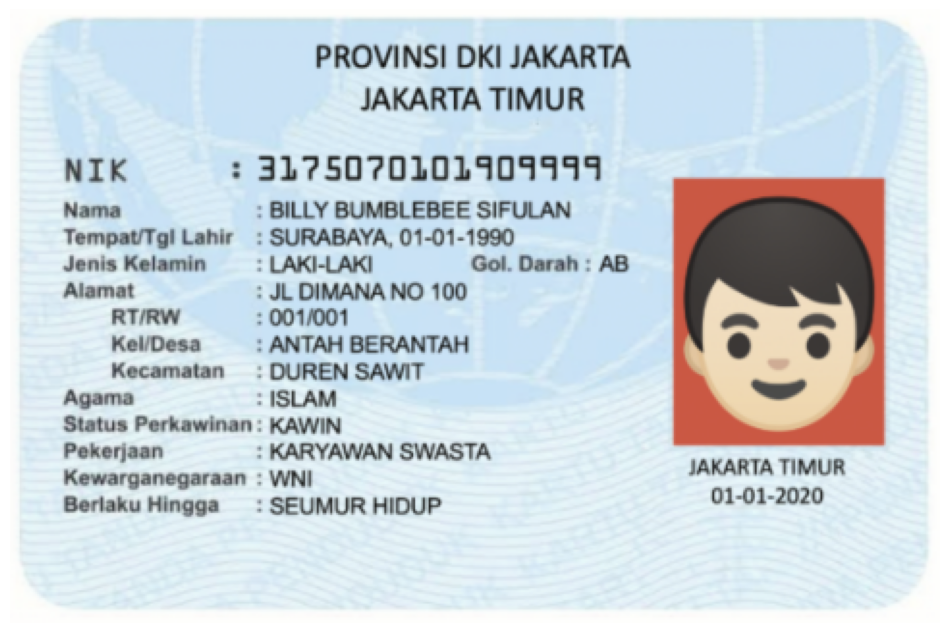

Shape setelah figsize besar: (318, 482, 3)


In [46]:
import cv2 as cv
import matplotlib.pyplot as plt

img = cv.imread("KTP.png")
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

print(f"Shape sebelum visualisasi: {img_rgb.shape}")

# Menampilkan dengan figsize kecil
plt.figure(figsize=(2, 2))
plt.imshow(img_rgb)
plt.axis("off")
plt.show()

# Menampilkan dengan figsize jauh lebih besar
plt.figure(figsize=(12, 12))
plt.imshow(img_rgb)
plt.axis("off")
plt.show()

print(f"Shape setelah figsize besar: {img_rgb.shape}")

**TUGAS PRAKTIKUM - Penerapan**

Berdasarkan praktikum bagian 1 dan 2 kerjakan beberapa tugas berikut :

1. Tampilkan citra hanya pada kombinasi kanal Merah-Biru dan kanal Hijau-Biru saja, dengan kanal yang tidak dipakai dinolkan. Susun keduanya berdampingan dalam satu figure yang diberi judul.


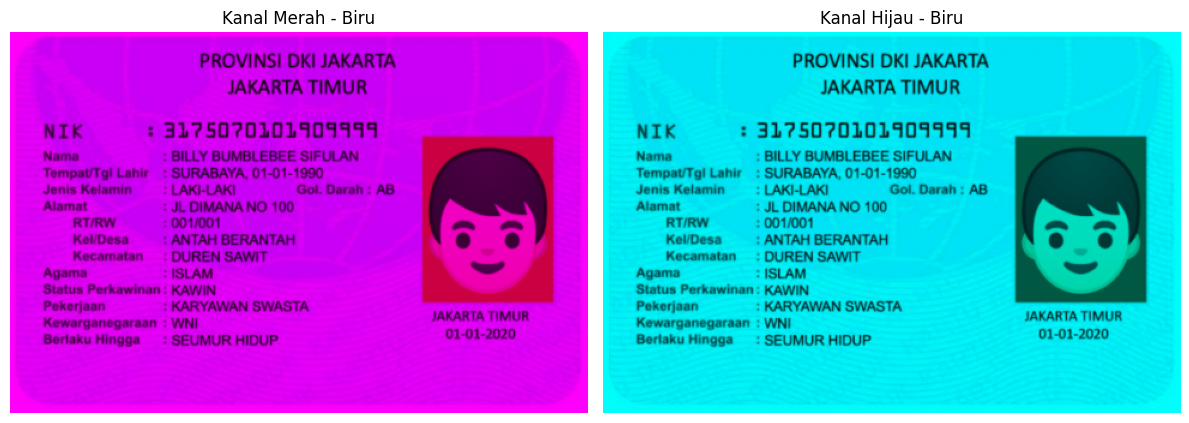

In [47]:
img = cv.imread("KTP.png")
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

img_rb = img_rgb.copy()
img_rb[:, :, 1] = 0

img_gb = img_rgb.copy()
img_gb[:, :, 0] = 0

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(img_rb)
axes[0].set_title("Kanal Merah - Biru")
axes[0].axis("off")

axes[1].imshow(img_gb)
axes[1].set_title("Kanal Hijau - Biru")
axes[1].axis("off")

plt.tight_layout()
plt.show()

2. Tampilkan citra dalam tiga bentuk pencerminan: vertikal, horizontal, dan keduanya, dalam satu figure berisi tiga subplot yang masing-masing diberi label.

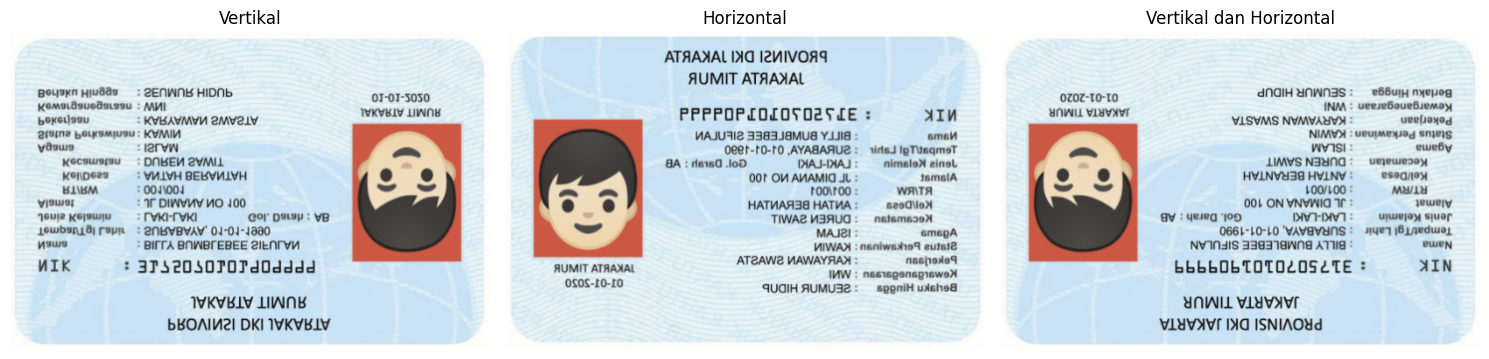

In [48]:
img = cv.imread("KTP.png")
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

flip_v = cv.flip(img_rgb, 0)
flip_h = cv.flip(img_rgb, 1)
flip_vh = cv.flip(img_rgb, -1)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(flip_v)
axes[0].set_title("Vertikal")
axes[0].axis("off")

axes[1].imshow(flip_h)
axes[1].set_title("Horizontal")
axes[1].axis("off")

axes[2].imshow(flip_vh)
axes[2].set_title("Vertikal dan Horizontal")
axes[2].axis("off")

plt.tight_layout()
plt.show()

3. Gambarkan sebuah rectangle dan sebuah circle pada bagian wajah / badan dari foto aktivitas Anda sendiri (bukan pasfoto), lalu tambahkan teks berisi nama Anda dengan pilihan font, ukuran, dan warna yang Anda tentukan sendiri.

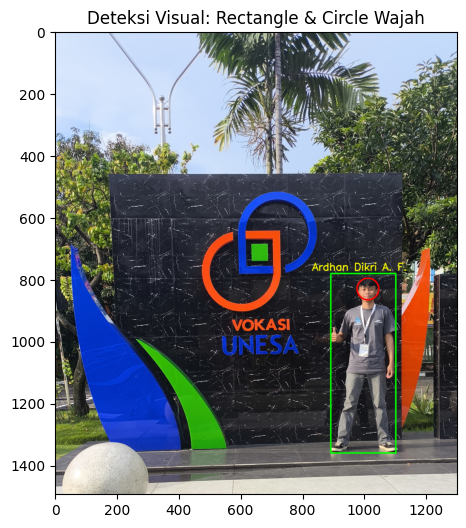

In [49]:
# Membaca foto pribadi beraktivitas
face = cv.imread('Aktivitas.jpg')
face = cv.cvtColor(face, cv.COLOR_BGR2RGB)
face = cv.resize(face, (0, 0), fx=0.5, fy=0.5)

img_face = face.copy()
cv.circle(img_face, center=(1010, 830), radius=35, color=(255, 0, 0), thickness=3)

cv.rectangle(
    img_face,
    pt1=(890, 780),
    pt2=(1100, 1360),
    color=(0, 255, 0),
    thickness=3,
)

cv.putText(
    img_face,
    text="Ardhan Dikri A. F.",
    org=(830, 770),
    fontFace=cv.FONT_HERSHEY_SIMPLEX,
    fontScale=1.1,
    color=(255, 255, 0),
    thickness=2,
    lineType=cv.LINE_AA,
)

plt.figure(figsize=(6, 6))
plt.imshow(img_face)
plt.title("Deteksi Visual: Rectangle & Circle Wajah")
plt.show()

**TUGAS PRAKTIKUM - Analisa**

1. Rumuskan satu pertanyaan tentang citra digital yang dapat Anda jawab menggunakan kode dari modul ini. Contoh pertanyaan: berapa persen piksel pada foto KTM Anda yang lebih gelap dari nilai 100? apakah mengecilkan lalu membesarkan citra mengubah rata-rata intensitasnya? Tuliskan pertanyaan Anda, rancangan program, data hasilnya, dan kesimpulan Anda.


**Jawaban**

1. Berapa persen piksel pada foto KTM yang tergolong gelap (nilai intensitas di bawah 100)?

Total Piksel       : 1374097
Piksel Gelap (<100): 87869
Persentase Gelap   : 6.39%


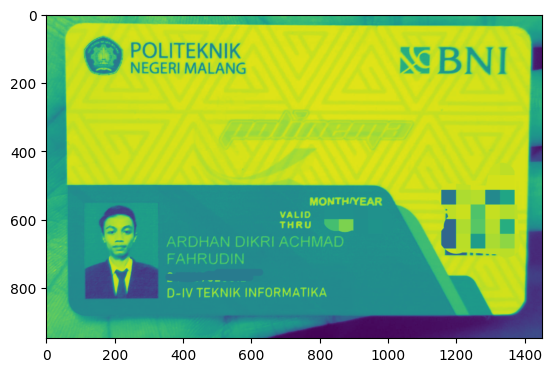

In [50]:
import cv2 as cv
import numpy as np

# 1. Baca citra mode grayscale
gray = cv.imread("KTM.jpeg", cv.IMREAD_GRAYSCALE)

# 2. Hitung piksel gelap (< 100)
total_piksel = gray.size
piksel_gelap = np.sum(gray < 100)
persen_gelap = (piksel_gelap / total_piksel) * 100
plt.imshow(gray)
# 3. Cetak hasil
print(f"Total Piksel       : {total_piksel}")
print(f"Piksel Gelap (<100): {piksel_gelap}")
print(f"Persentase Gelap   : {persen_gelap:.2f}%")

**TUGAS PRAKTIKUM - Aplikasi**

Pada bagian ini, Anda hanya diperbolehkan memakai fungsi yang telah dipelajari pada modul ini: pembacaan berkas, pengirisan, cv2.resize, cv2.flip, cv2.cvtColor, fungsi penggambaran OpenCV, serta pembuatan kanvas dengan NumPy. Selain itu, program harus bersifat adaptif, dimana setiap ukuran, posisi, atau ketebalan harus dihitung dari ukuran citra masukan, bukan ditulis sebagai angka tetap pada kode program.

**Studi Kasus 1**: Panitia sebuah kegiatan perlu membubuhkan label identitas pada ratusan foto dokumentasi. Foto berasal dari beberapa kamera dan ponsel, sehingga ukurannya bermacam-macam. Label harus terlihat seimbang pada semua foto tanpa disetel satu per satu. Fungsi yang sama dikenakan pada dua citra berbeda ukuran. Tinggi bar dan ukuran huruf ikut menyesuaikan, sehingga proporsinya tetap sama.


--- 1. Hasil Landscape (900 x 600 px) | Bar: 50 px ---


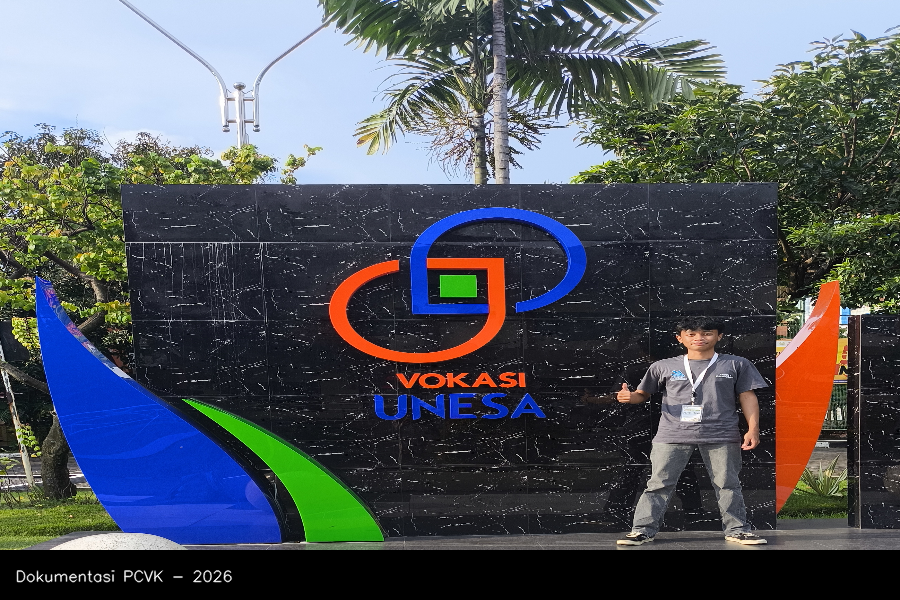


--- 2. Hasil Portrait (480 x 760 px) | Bar: 63 px ---


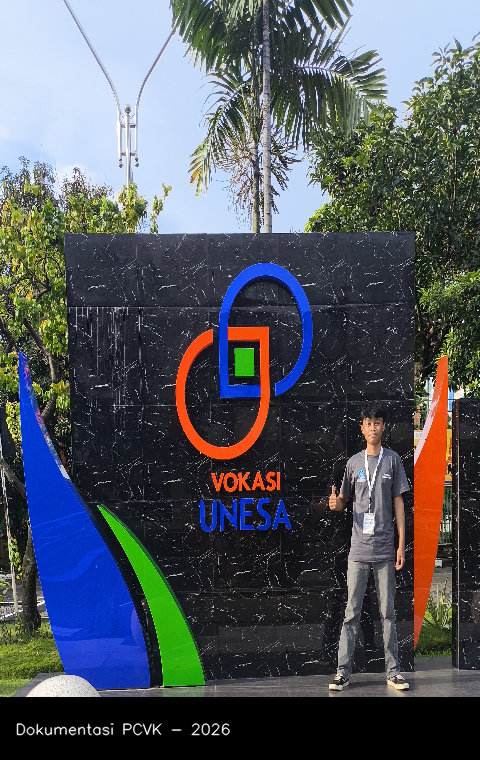

In [51]:
import cv2
from google.colab.patches import cv2_imshow


def beri_dokumentasi(image, label):
    h, w, _ = image.shape
    bar_height = h // 12

    image[h - bar_height : h, 0 : w] = [0, 0, 0]

    text = "Dokumentasi PCVK - 2026"
    font = cv2.FONT_HERSHEY_SIMPLEX

    max_text_width = int(w * 0.45)
    max_text_height = int(bar_height * 0.25)

    font_scale = 0.5
    thickness = 1

    (tw, th), _ = cv2.getTextSize(text, font, font_scale, thickness)

    if tw > max_text_width:
        font_scale *= max_text_width / tw
    if th > max_text_height:
        font_scale *= max_text_height / th

    (tw, th), _ = cv2.getTextSize(text, font, font_scale, thickness)

    x_pos = 15
    y_pos = int(h - (bar_height - th) / 2)

    cv2.putText(
        image,
        text,
        (x_pos, y_pos),
        font,
        font_scale,
        (255, 255, 255),
        thickness,
        cv2.LINE_AA,
    )

    print(f"\n--- {label} ({w} x {h} px) | Bar: {bar_height} px ---")
    cv2_imshow(image)

img_asli = cv2.imread("Aktivitas.jpg")

img_landscape = cv2.resize(img_asli, (900, 600))
beri_dokumentasi(img_landscape, "1. Hasil Landscape")

img_portrait = cv2.resize(img_asli, (480, 760))
beri_dokumentasi(img_portrait, "2. Hasil Portrait")

**Studi Kasus 2:** Marketplace seperti Tokopedia dan Shopee menampilkan foto produk dalam bingkai persegi 1:1. Foto penjual yang berukuran potrait atau lanskap akan terpotong atau terlihat tidak proporsional bila diunggah begitu saja. Bangun program yang mengubah foto berukuran apa pun menjadi thumbnail persegi tanpa mengubah rasio aslinya, dengan sisa ruang diisi kanvas berwarna. Dalam hal ini, rasio asli tetap terjaga, citra terpasang tepat di tengah kanvas, tambahkan logo nama toko berukuran proporsional pada gambar.


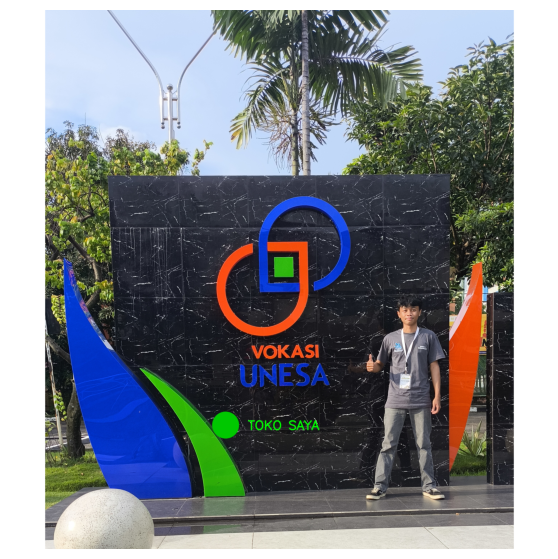

In [69]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('/content/drive/MyDrive/PCVK/Aktivitas.jpg')
h, w = img.shape[:2]

s = max(h, w)
kanvas = np.full((s, s, 3), 255, dtype=np.uint8)

y_offset = (s - h) // 2
x_offset = (s - w) // 2
kanvas[y_offset:y_offset + h, x_offset:x_offset + w] = img

nama_toko = "TOKO SAYA"
font = cv2.FONT_HERSHEY_SIMPLEX
font_scale = s / 1300.0
font_thick = max(1, s // 450)
r = s // 40
jarak_logo_teks = int(r * 0.7)

(w_teks, h_teks), _ = cv2.getTextSize(nama_toko, font, font_scale, font_thick)

cx = int(s * 0.40)
cy = int(s * 0.77)

x_teks = cx + r + jarak_logo_teks
y_teks = cy + (h_teks // 2)

cv2.circle(kanvas, (cx, cy), r, (0, 200, 0), -1, cv2.LINE_AA)
cv2.putText(kanvas, nama_toko, (x_teks, y_teks), font, font_scale, (0, 255, 0), font_thick, cv2.LINE_AA)

plt.figure(figsize=(7, 7))
plt.imshow(cv2.cvtColor(kanvas, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()